## Análisis exploratorio

In [2]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carga de datasets
movimientos = pd.read_csv("../dataset/movimientos.csv")
stock = pd.read_csv("../dataset/stock.csv")
productos = pd.read_csv("../dataset/productos.csv")

# Normalizar fechas
movimientos['fecha'] = pd.to_datetime(movimientos['fecha'])
stock['fecha'] = pd.to_datetime(stock['fecha'])

In [4]:
# Verificar si los gtin son consistentes en los datasets
gtins_movimientos = set(movimientos['gtin'].unique())
gtins_productos = set(productos['gtin'].unique())
gtins_stock = set(stock['gtin'].unique())

print(f"Códigos GTIN únicos en movimientos: {len(gtins_movimientos)}")
print(f"Códigos GTIN únicos en listado de productos: {len(gtins_productos)}")
print(f"Códigos GTIN únicos en stock: {len(gtins_productos)}")

print(f"son_identicos_mov_prod = {gtins_movimientos == gtins_productos}")
print(f"son_identicos_stock_prod = {gtins_stock == gtins_productos}")

Códigos GTIN únicos en movimientos: 36
Códigos GTIN únicos en listado de productos: 36
Códigos GTIN únicos en stock: 36
son_identicos_mov_prod = True
son_identicos_stock_prod = True


In [5]:
# Verificar si hay dias con mas de una salida o entrada
conteo_registros = movimientos.groupby(['gtin', 'fecha', 'tipo_movimiento']).size()

print("Registros por dia:")
print(conteo_registros.value_counts())


# Verificar si hay dias sin consumo 
fecha_min = movimientos['fecha'].min().date()
fecha_max = movimientos['fecha'].max().date()
dias_unicos = movimientos['fecha'].nunique()
dias_teoricos = (movimientos['fecha'].max() - movimientos['fecha'].min()).days + 1

print(f"Tabla movimientos Rango: Desde {fecha_min} hasta {fecha_max}")
print(f"Días con registros: {dias_unicos} de {dias_teoricos} teóricos")

Registros por dia:
1    12533
Name: count, dtype: int64
Tabla movimientos Rango: Desde 2024-01-02 hasta 2026-07-01
Días con registros: 912 de 912 teóricos


In [6]:
# Filtrar solo las salidas (consumo)
consumo = movimientos[movimientos['tipo_movimiento'] == 'S'].copy()

# Unir el catálogo de productos para ver nombres y líneas terapéuticas
consumo_enriquecido = consumo.merge(productos, on="gtin", how="left")

# Asignar etiqueta "otro" a productos sin linea terapeutica
consumo_enriquecido['linea_terapeutica'] = consumo_enriquecido['linea_terapeutica'].fillna('OTRO')

# Descriptivos por producto ordenados por consumo total
descriptivos_productos = consumo_enriquecido.groupby(['gtin', 'material', 'linea_terapeutica'])['cantidad'].agg(
    dias_con_consumo='count',
    consumo_total='sum',
    promedio_diario='mean',
    maximo_unidades='max',
    desviacion_estandar='std'
).sort_values(by='consumo_total', ascending=False).reset_index()

descriptivos_productos

,gtin,material,linea_terapeutica,dias_con_consumo,consumo_total,promedio_diario,maximo_unidades,desviacion_estandar
0,7837519364827,DULAGLUTIDA,ENFERMEDADES_CRONICAS,130,4433,34.100000,186,20.092364
1,7841759382640,LIDOCAÍNA 2%,QUIRURGICO,127,4243,33.409449,101,14.086104
2,7825148963720,APIXABÁN 5 MG,CARDIOVASCULAR,131,4238,32.351145,85,13.071945
3,7836184297355,SACUBITRILO/VALSARTÁN,CARDIOVASCULAR,132,4156,31.484848,86,12.910428
4,7832948571630,INSULINA GLARGINA,ENFERMEDADES_CRONICAS,127,4018,31.637795,93,13.841890
5,7821638475297,DAPAGLIFLOZINA 10 MG,ENFERMEDADES_CRONICAS,127,3950,31.102362,88,13.656695
6,7846284917531,KETOROLACO,QUIRURGICO,117,3885,33.205128,138,16.197881
7,7846735281945,ADRENALINA AUTOINYECTABLE,EMERGENCIAS,108,3770,34.907407,132,20.365142
8,7847516283949,ONDANSETRÓN,OTRO,548,3704,6.759124,18,3.303149
9,7823871649526,RIVAROXABÁN 20 MG,CARDIOVASCULAR,119,3704,31.126050,59,12.888409


Obs: A partir de los descriptivos de consumo, se puede concluir que existen medicamentos de alta rotación (consumo constante diario) con promedio diario alredor de 6 unidades. Mientras que otros tienen un patron diario de consumo bajo o medio pero con mayor cantidad consumida promedio. Lo anterior sugiere que existen comportamientos de consumo diferentes dentro de la muestra, resultando relevante para una posterior planificación de abastecimiento. 

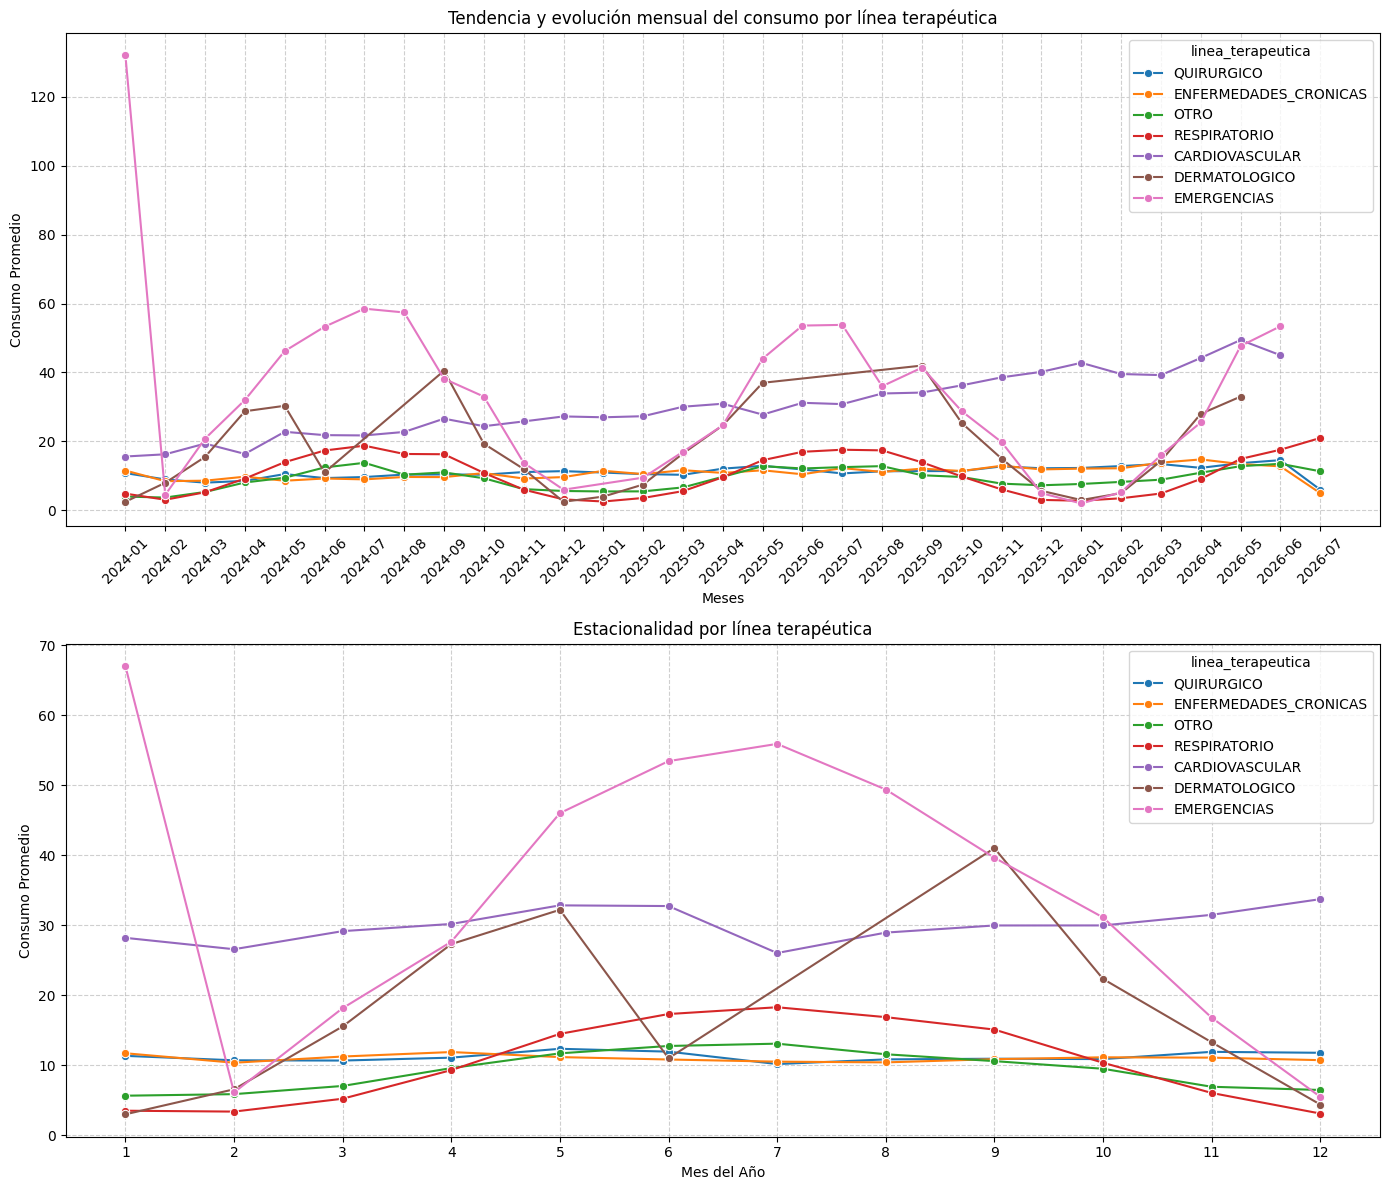

In [7]:
# Crear componentes de tiempo para el análisis de tendencias y meses
consumo_enriquecido['mes'] = consumo_enriquecido['fecha'].dt.month
consumo_enriquecido['año_mes'] = consumo_enriquecido['fecha'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico consumo promedio en el tiempo por línea terapéutica
sns.lineplot(
    data=consumo_enriquecido, 
    x='año_mes', 
    y='cantidad', 
    hue='linea_terapeutica', 
    ax=axes[0], 
    marker='o',
    errorbar=None
)
axes[0].set_title("Tendencia y evolución mensual del consumo por línea terapéutica")
axes[0].set_xlabel("Meses")
axes[0].set_ylabel("Consumo Promedio")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico de estacionalidad por linea terapéutica 
sns.lineplot(
    data=consumo_enriquecido, 
    x='mes', 
    y='cantidad', 
    hue='linea_terapeutica', 
    ax=axes[1], 
    marker='o',
    errorbar=None
)
axes[1].set_title("Estacionalidad por línea terapéutica")
axes[1].set_xlabel("Mes del Año")
axes[1].set_ylabel("Consumo Promedio")
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

La gráfica de tendencia y estacionalidad por linea terapéutica arroja un claro patrón de consumo por línea. Se distingue tres agrupaciones o clusters según consumo:
 - Grupo de medicamentos de tendencia al alza sin estacionalidad (cardiovasculares)
 - Grupo de medicamentos con estacionalidad invernal (emergencias, dermatológicos y respiratorios)
 - Grupo de medicamentos con inelasticidad de consumo temporal (enfermedades crónicas y quirúrgicos)

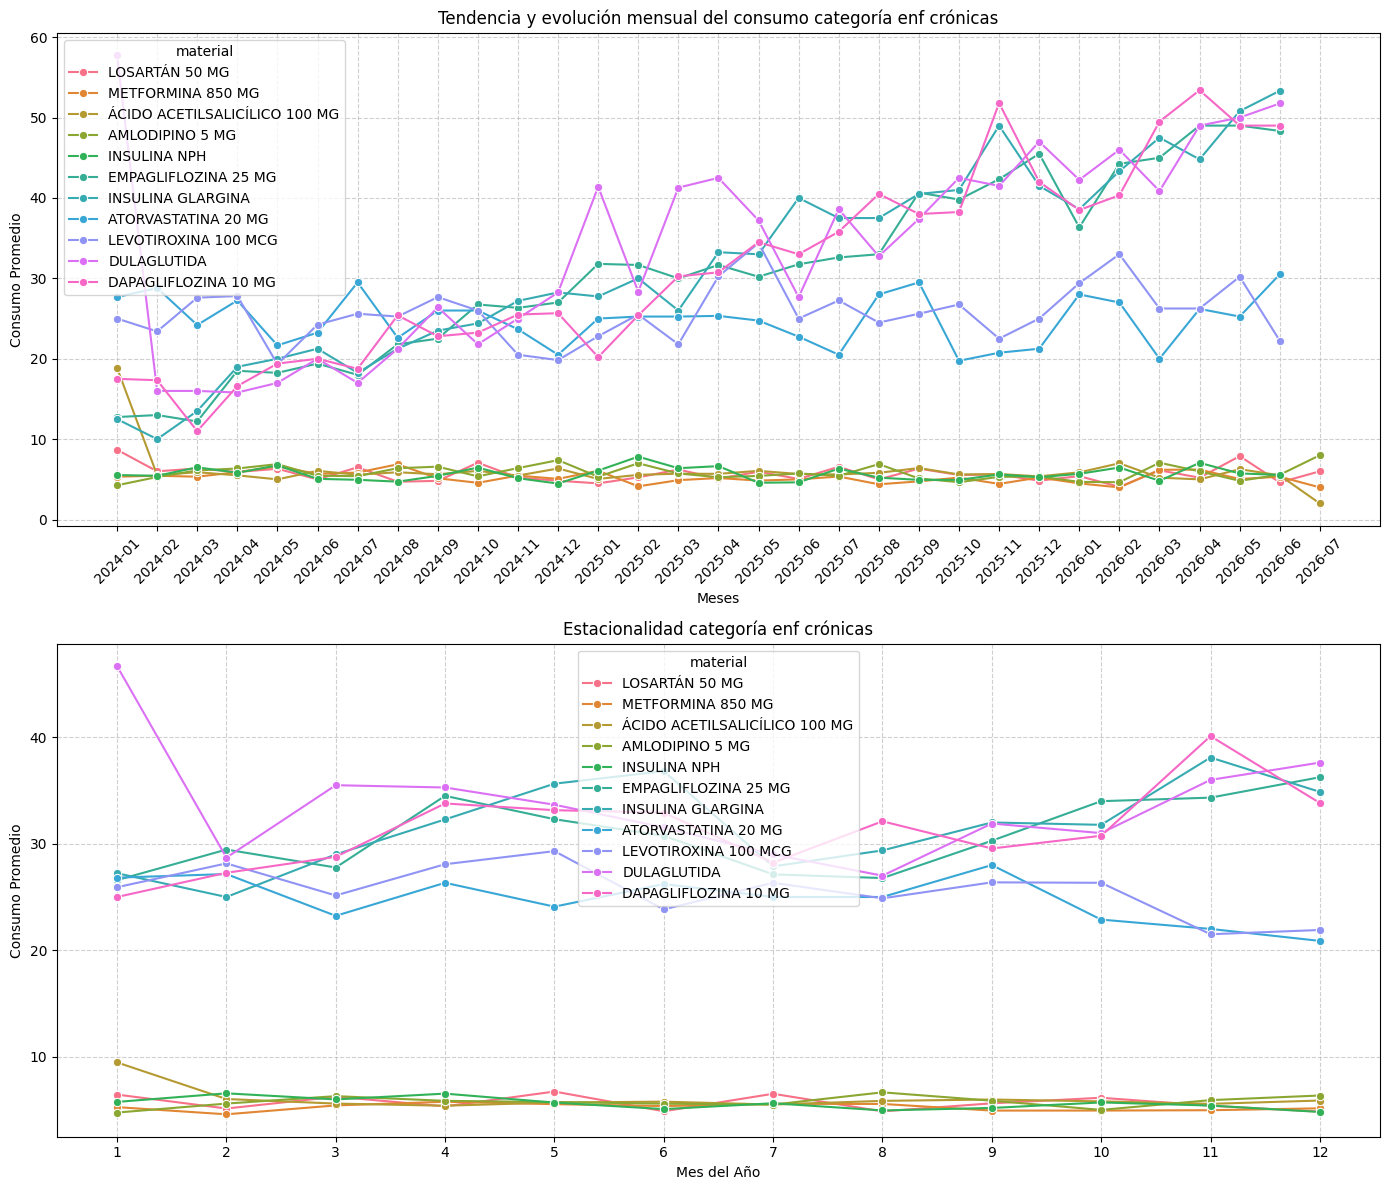

In [ ]:
# Analisis de tendencia y estacionalidad de medicamentos de enfermedades crónicas
consumo_enf_cronicas = consumo_enriquecido[consumo_enriquecido['linea_terapeutica'] == 'ENFERMEDADES_CRONICAS']

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico consumo promedio en el tiempo
sns.lineplot(
    data=consumo_enf_cronicas, 
    x='año_mes', 
    y='cantidad', 
    hue='material', 
    ax=axes[0], 
    marker='o',
    errorbar=None
)
axes[0].set_title("Tendencia y evolución mensual del consumo categoría enf crónicas")
axes[0].set_xlabel("Meses")
axes[0].set_ylabel("Consumo Promedio")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico de estacionalidad
sns.lineplot(
    data=consumo_enf_cronicas, 
    x='mes', 
    y='cantidad', 
    hue='material', 
    ax=axes[1], 
    marker='o',
    errorbar=None
)
axes[1].set_title("Estacionalidad categoría enf crónicas")
axes[1].set_xlabel("Mes del Año")
axes[1].set_ylabel("Consumo Promedio")
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Analisis intrasemanal (efecto dia semana)

C:\Users\pcfam\AppData\Local\Temp\ipykernel_8728\3738549396.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


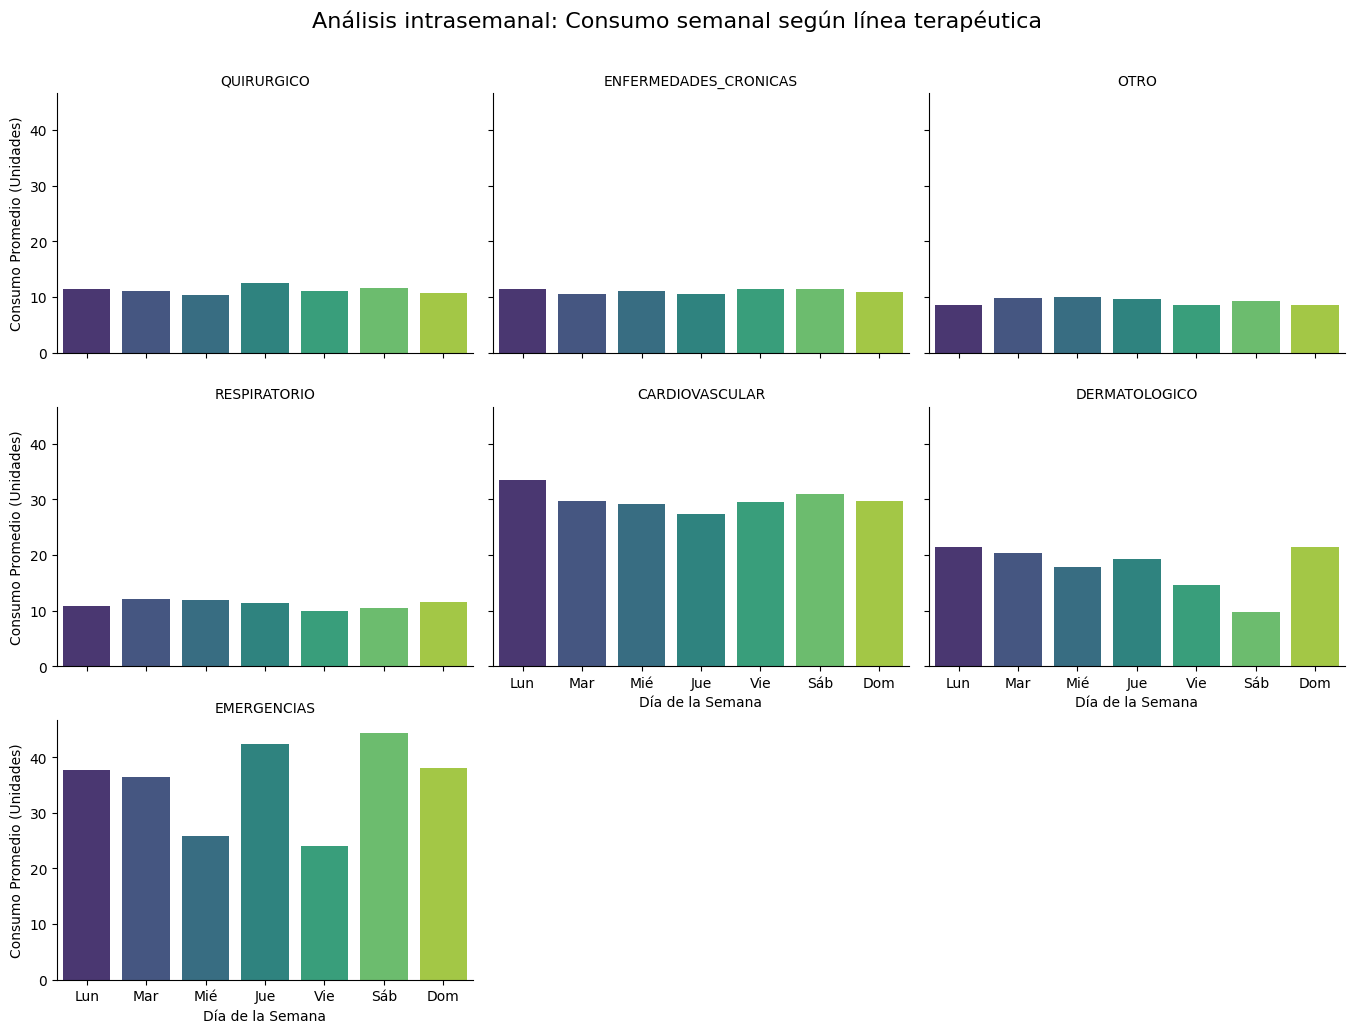

In [ ]:
# Analisis intrasemanal (efecto dia de la semana)

# Configurar la variable del día de la semana (0=Lunes, 6=Domingo)
consumo_enriquecido['dia_semana'] = consumo_enriquecido['fecha'].dt.dayofweek

# Gráfico facetado por línea terapéutica
g = sns.catplot(
    data=consumo_enriquecido, 
    x='dia_semana', 
    y='cantidad', 
    col='linea_terapeutica', 
    col_wrap=3, 
    kind='bar', 
    palette='viridis',
    errorbar=None,
    height=3.5, 
    aspect=1.3
)

# Configurar etiquetas para el eje X
g.set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
g.set_titles("{col_name}")
g.set_axis_labels("Día de la Semana", "Consumo Promedio (Unidades)")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Análisis intrasemanal: Consumo semanal según línea terapéutica", fontsize=16)
plt.show()

Obs: Existe una regularidad de consumo promedio intrasemanal para casi todas las lineas terapéuticas, es decir que no existirían shocks de consumo para estos datos, a diferencia de una farmacia donde el mayor consumo podría situarse los fines de semana. Sin embargo, a nivel individual si podrian existir patrones como el caso de medicamento dermatologico, que tiene una caída los dias sábados. 